In [6]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from xgboost import XGBRegressor
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [9]:
# df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoder = LabelEncoder()

# Ensure categorical features are strings (clean)
categorical_cols = [
    'scac', 'delivery_terms',
    'po_shipment_terms', 'tariff_type', 'item_brand',
    'item_manufacturer', 'item_product_category',
    'item_size', 'vendor_name'
]

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype(str).str.strip().replace('', 'Unknown')

for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))


In [10]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = [
    "tariff_amount",
    "quantity_in",
    "ocean_freight",
]

scaler = StandardScaler()
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

In [11]:
df_encoded

,delay_days,shipping_duration_days,lead_time_days,is_early_delivery,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,tariff_type,...,vendor_name,vendor_avg_delay_days,vendor_shipments,vendor_on_time_rate,vendor_p50_delay_days,vendor_p90_delay_days,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,7,21,60,0,9,1.632126,-0.559174,0,2,1,...,3,5.80,5,0.0,5,11,4,9,26,2100
1,4,53,108,0,5,2.581984,0.942012,1,2,1,...,0,3.33,12,0.0,4,4,5,8,23,6200
2,4,53,108,0,5,2.581984,0.942012,1,2,1,...,0,3.33,12,0.0,4,4,5,8,23,6200
3,4,70,89,0,5,5.542943,2.383492,0,2,1,...,1,4.38,96,0.0,4,6,1,8,5,11000
4,5,60,276,0,2,1.936878,1.239690,0,2,1,...,8,3.35,20,0.0,3,5,3,8,14,8200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797,4,39,100,0,6,-0.409707,-0.559174,1,2,0,...,13,3.42,62,0.0,3,6,4,6,30,6000
798,2,37,53,0,6,-0.409707,-0.559174,1,2,0,...,13,3.42,62,0.0,3,6,6,5,14,6000
799,3,38,53,0,6,-0.409707,-0.559174,1,2,0,...,13,3.42,62,0.0,3,6,6,5,14,6000
800,2,37,53,0,6,-0.409707,-0.559174,1,2,0,...,13,3.42,62,0.0,3,6,6,5,14,6000


In [12]:
X = df_encoded.drop('delay_days', axis=1)
y = df_encoded['delay_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Ranking the models based on the error produced

In [13]:
models = {
    "Huber": HuberRegressor(),
    "DecisionTree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42, loss='huber'),
    # "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "LinearRegression": LinearRegression()
}

In [14]:
# --- Weighted fitting (simulate 'class_weight=balanced') ---
weights = 1 + (y_train / y_train.max())  # or np.exp(y_train / y_train.max())

results = []
for name, model in models.items():
    try:
        model.fit(X_train, y_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, y_train)  # For models that don't support weighting
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append((name, mae, rmse, r2))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(results_df.sort_values(by="RMSE"))

              Model       MAE      RMSE        R2
3  GradientBoosting  1.350535  2.002468  0.872800
2      RandomForest  1.403043  2.142381  0.854404
1      DecisionTree  1.448155  2.203710  0.845948
5             Lasso  3.057854  4.441144  0.374327
4             Ridge  3.069783  4.446971  0.372684
6  LinearRegression  3.099150  4.508236  0.355281
0             Huber  1.881896  5.099163  0.175188


## Gradient Boosting

## Inferencing for Gradient Boosting

In [15]:
X.columns

Index(['shipping_duration_days', 'lead_time_days', 'is_early_delivery', 'scac',
       'tariff_amount', 'ocean_freight', 'delivery_terms', 'po_shipment_terms',
       'tariff_type', 'total_bcy', 'quantity_in', 'item_sku', 'item_brand',
       'item_manufacturer', 'item_product_category', 'item_size',
       'vendor_name', 'vendor_avg_delay_days', 'vendor_shipments',
       'vendor_on_time_rate', 'vendor_p50_delay_days', 'vendor_p90_delay_days',
       'shipped_date_weekday', 'shipped_date_month', 'shipped_date_day',
       'distance_nm'],
      dtype='object')

In [16]:
new_data

NameError: name 'new_data' is not defined

Predicted Delay Days: 6.79


In [ ]:
is_predicted_delayed = int(predicted_delay_days[0] > 5)
print("Predicted Class:", "DELAYED" if is_predicted_delayed else "ON-TIME")

Predicted Class: DELAYED


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-603834-8qij21fj for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-603834-ro48kjf5 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-603834-gass40mu for automatic cleanup

## Explaning the gradient boosting result

/home/prashant/.pyenv/versions/3.13.2/envs/ideabox-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


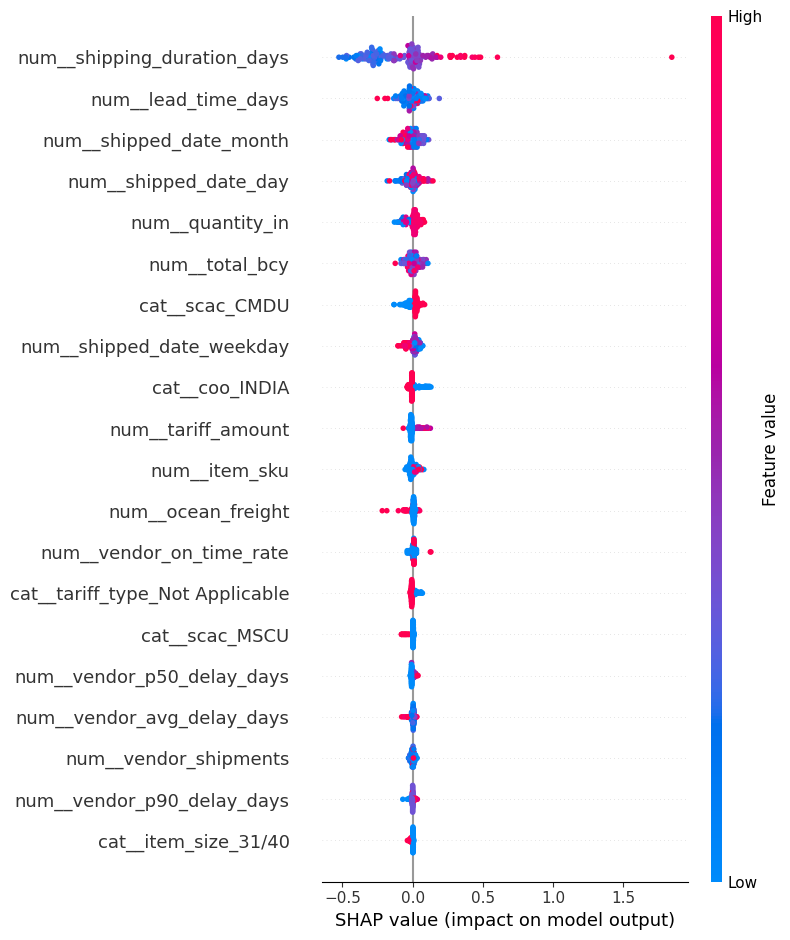

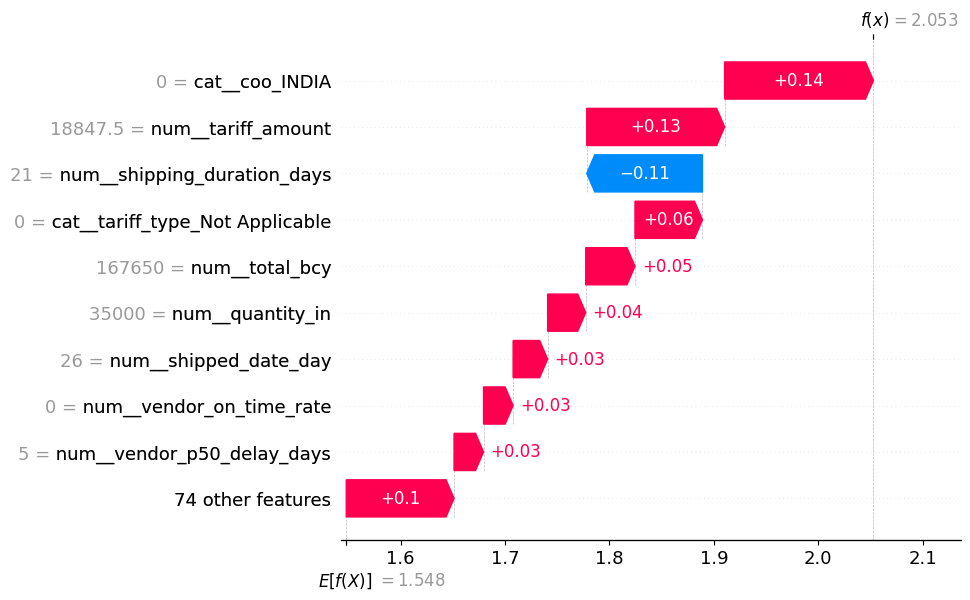

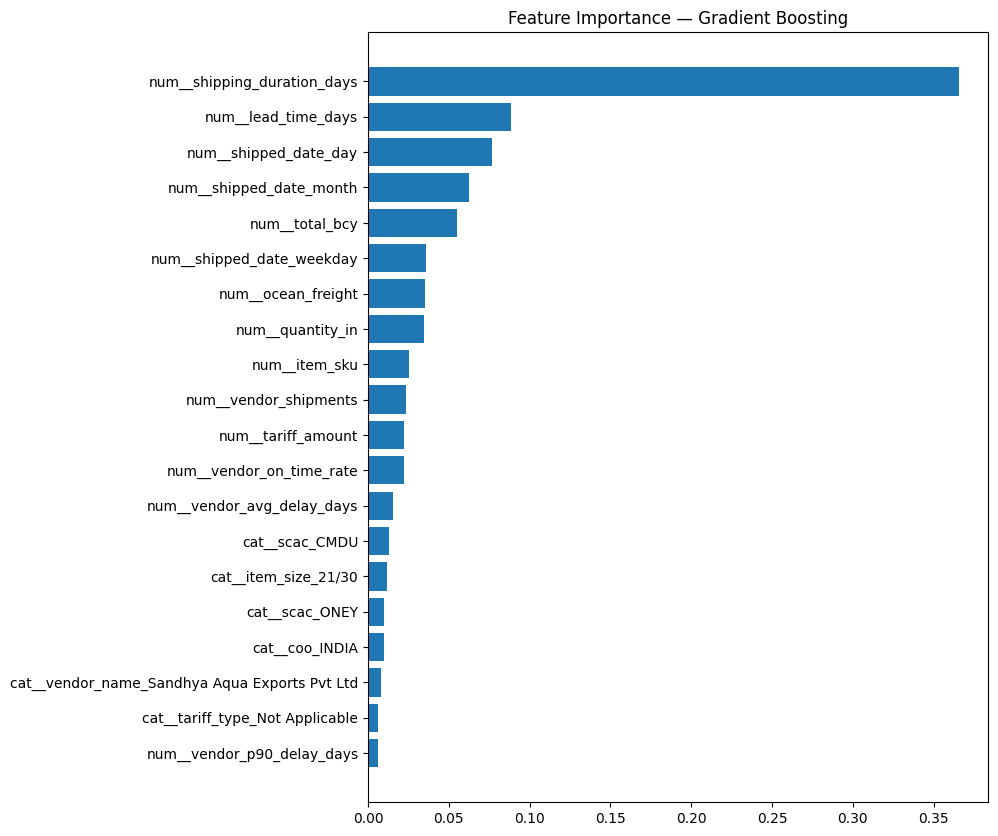

## Explanaing using the LLM

In [ ]:
from openai import OpenAI
from dotenv import load_dotenv
import os
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
system_prompt = """You are an expert data scientist specializing in machine learning model explanations. 
Your task is to help explain the predictions of a Gradient Boosting regression model trained to predict shipment delay days.
When given feature values for a shipment, provide a clear, concise explanation of features contributes to the predicted delay days.
Focus on the most impactful features and their influence on the prediction.
Try to keep the explanation based on the data provided.
Try to find the root cause behind the delay.
Avoid using technical jargon; explain in simple terms.
Try to explain the predictions in 2 lines at maximum.

Here is the idea behind the features provided:
- shipping_duration_days: Expected duration of the shipment in days.
- lead_time_days: Number of days between order placement and shipment.
- is_early_delivery: Indicator if the delivery was early (1) or not (0).
- coo: Country of origin of the shipment.
- scac: Standard Carrier Alpha Code representing the shipping carrier.
- tariff_amount: The tariff cost associated with the shipment.
- ocean_freight: Cost of ocean freight for the shipment.
- delivery_terms: Terms of delivery (e.g., CY, DDP).
- po_shipment_terms: Purchase order shipment terms.
- tariff_type: Type of tariff applied to the shipment.
- total_bcy: Total cost in base currency.
- quantity_in: Quantity of items in the shipment.
- item_sku: Stock Keeping Unit identifier for the item.
- item_brand: Brand of the item being shipped.
- item_manufacturer: Manufacturer of the item.
- item_product_category: Category of the product being shipped.
- item_size: Size specification of the item.
- vendor_name: Name of the vendor supplying the item.
- vendor_avg_delay_days: Average delay days for shipments from this vendor.
- vendor_shipments: Total number of shipments made by this vendor.
- vendor_on_time_rate: Percentage of on-time deliveries by this vendor.
- vendor_p50_delay_days: 50th percentile delay days for this vendor.
- vendor_p90_delay_days: 90th percentile delay days for this vendor.
- shipped_date_weekday: Day of the week the shipment was sent (0=Monday, 6=Sunday).
- shipped_date_month: Month the shipment was sent (1-12).
- shipped_date_day: Day of the month the shipment was sent (1-31).
"""

user_query = f"""Given the following feature values for a shipment:
{new_data.to_dict(orient='records')[0]}
The model predicted a delay of {predicted_delay_days[0]:.2f} days.
Please explain how the key features influenced this prediction.
Shap values for the features are:
{shap_values_single.values[0]}
"""


In [ ]:
print(system_prompt)

You are an expert data scientist specializing in machine learning model explanations. 
Your task is to help explain the predictions of a Gradient Boosting regression model trained to predict shipment delay days.
When given feature values for a shipment, provide a clear, concise explanation of features contributes to the predicted delay days.
Focus on the most impactful features and their influence on the prediction.
Try to keep the explanation based on the data provided.
Try to find the root cause behind the delay.
Avoid using technical jargon; explain in simple terms.
Try to explain the predictions in 2 lines at maximum.

Here is the idea behind the features provided:
- shipping_duration_days: Expected duration of the shipment in days.
- lead_time_days: Number of days between order placement and shipment.
- is_early_delivery: Indicator if the delivery was early (1) or not (0).
- coo: Country of origin of the shipment.
- scac: Standard Carrier Alpha Code representing the shipping carri

In [ ]:
response = client.chat.completions.create(
    model="gpt-4",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query}
    ],
    max_tokens=500,
    temperature=0.7
)

In [ ]:
print(response.choices[0].message.content)

The predicted delay of nearly 7 days is primarily due to the vendor's historical delay data. The vendor typically has an average delay of 5.8 days and doesn't have an on-time delivery track record. This impacts the prediction significantly. Other contributing factors include the country of origin, Ecuador, the tariff amount, and the shipping duration. These factors combined with the vendor's delay history are the root cause of the predicted delay.


In [ ]:
import pandas as pd

# Define the data
data = [
    [7, 21, 60, 0, "ECUADOR", "SMLU", 18847.5, 0.0, "CY", "DDP", "Price With Tariff",
     167650.0, 35000.0, "855", "GREAT VALUE", "VANNAMEI", "Goods", "26/30", "IPSP, INC.",
     5.8, 5, 0.0, 5, 11, 4, 9, 26],
    
    [4, 53, 108, 0, "VIETNAM", "MAEU", 27615.34, 3520.0, "Door Delivered", "DDP", "Price With Tariff",
     160729.92, 29892.0, "1994", "MARKET SIDE", "AHI TUNA", "Goods", "3.5-5 OZ", "Anova",
     3.33, 12, 0.0, 4, 4, 5, 8, 23],
    
    [4, 53, 108, 0, "VIETNAM", "MAEU", 27615.34, 3520.0, "Door Delivered", "DDP", "Price With Tariff",
     160729.92, 4452.0, "1994", "MARKET SIDE", "AHI TUNA", "Goods", "3.5-5 OZ", "Anova",
     3.33, 12, 0.0, 4, 4, 5, 8, 23],
    
    [4, 70, 89, 0, "INDIA", "MAEU", 54947.0, 6900.0, "CY", "DDP", "Price With Tariff",
     181156.5, 34020.0, "857", "GREAT VALUE", "VANNAMEI", "Goods", "71/90", 
     "Aquatica Frozen Foods Global Pvt Ltd", 4.38, 96, 0.0, 4, 6, 1, 8, 5],
    
    [5, 60, 276, 0, "INDONESIA", "EGLV", 21660.57, 4218.0, "CY", "DDP", "Price With Tariff",
     145353.6, 35280.0, "865", "GREAT VALUE", "VANNAMEI", "Goods", "21/25", 
     "PT KHOM FOODS", 3.35, 20, 0.0, 3, 5, 3, 8, 14]
]

# Define the column names
columns = [
    "delay_days", "shipping_duration_days", "lead_time_days", "is_early_delivery", 
    "coo", "scac", "tariff_amount", "ocean_freight", "delivery_terms", "po_shipment_terms",
    "tariff_type", "total_bcy", "quantity_in", "item_sku", "item_brand", 
    "item_manufacturer", "item_product_category", "item_size", "vendor_name", 
    "vendor_avg_delay_days", "vendor_shipments", "vendor_on_time_rate", 
    "vendor_p50_delay_days", "vendor_p90_delay_days", "shipped_date_weekday", 
    "shipped_date_month", "shipped_date_day"
]

# Create the DataFrame
df_new = pd.DataFrame(data, columns=columns)

# Display
print(df_new)


   delay_days  shipping_duration_days  lead_time_days  is_early_delivery  \
0           7                      21              60                  0   
1           4                      53             108                  0   
2           4                      53             108                  0   
3           4                      70              89                  0   
4           5                      60             276                  0   

         coo  scac  tariff_amount  ocean_freight  delivery_terms  \
0    ECUADOR  SMLU       18847.50            0.0              CY   
1    VIETNAM  MAEU       27615.34         3520.0  Door Delivered   
2    VIETNAM  MAEU       27615.34         3520.0  Door Delivered   
3      INDIA  MAEU       54947.00         6900.0              CY   
4  INDONESIA  EGLV       21660.57         4218.0              CY   

  po_shipment_terms  ... item_size                           vendor_name  \
0               DDP  ...     26/30                        

In [ ]:
# Drop target if you're predicting (we already have delay_days here, but we can ignore it)
X_new = df_new.drop(columns=["delay_days"])

# Predict delay days
pred_log = best_gbr.predict(X_new)
pred_days = np.expm1(pred_log)
df_new["predicted_delay_days"] = pred_days.round(2)

# Derive classification (delayed vs not delayed)
df_new["predicted_is_delayed"] = (df_new["predicted_delay_days"] > 5).astype(int)

print(df_new[["vendor_name", "coo", "predicted_delay_days", "predicted_is_delayed"]])


                            vendor_name        coo  predicted_delay_days  \
0                            IPSP, INC.    ECUADOR                  6.79   
1                                 Anova    VIETNAM                  3.85   
2                                 Anova    VIETNAM                  3.49   
3  Aquatica Frozen Foods Global Pvt Ltd      INDIA                  3.68   
4                         PT KHOM FOODS  INDONESIA                  5.04   

   predicted_is_delayed  
0                     1  
1                     0  
2                     0  
3                     0  
4                     1  
